# Papalexi ECCITE-seq demo

An interactive tour of one complete `petrubseq-protein` run on the bundled Papalexi ECCITE-seq subset. The pipeline is run by the CLI (section 2); this notebook only loads and displays what that run produced. `report.html` in the run directory is the complete, automatically generated report.

## 1. Dataset

Papalexi E. *et al.*, Nat Genet 53:322 (2021), GEO GSE153056, pooled ECCITE-seq screen in IFN-γ stimulated THP-1 cells. The repository bundles a deterministic 1,800-cell subset (`demo/data/papalexi_eccite/`): RNA (18,649 genes, raw UMI counts), guide UMI counts (111 sgRNAs: 25 gene targets, 9 non-targeting `NT`, 1 eGFP), four ADTs (CD86, PD-L1 `PDL1`, PD-L2 `PDL2`, TIM-3 `CD366`), three hashed samples over eight lanes. All cells are IFN-γ stimulated; there are no isotype controls. It is a demonstration subset, not a reanalysis of the paper.

## 2. Run the pipeline

```bash
conda activate petrubseq-protein
petrubseq-protein run --config config/demo_papalexi.yaml
```

Output is written to `${RESULTS_ROOT}/demo/papalexi_eccite/` (`../results/` next to the repository, or `PETRUBSEQ_RESULTS_ROOT`). The config runs the reference-compatible RNA analyses (QC, Leiden clustering, perturbation strength, perturbation x cluster enrichment, modules / gene programs, PS with the LDA embedding, lochNESS) and the protein extension (protein QC, CLR, PCA/UMAP, target x protein effects, RNA-protein concordance). This notebook only reads what that run stored; nothing is recomputed here.

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = Path(os.environ.get("PETRUBSEQ_RESULTS_ROOT", REPO.parent / "results")) / "demo" / "papalexi_eccite"
T = RESULTS / "tables"
pd.set_option("display.width", 200, "display.max_columns", 30)

cfg = (REPO / "config" / "demo_papalexi.yaml").read_text()
print(cfg[cfg.index("analysis:"):])

analysis:
  perturbation_effects:
    enabled: true
    control_classes: [non_targeting]     # the NT guides; eGFP (transgene) cells are neither perturbed nor control
    target_gene_map:
      PDL1: CD274                        # dataset label -> RNA gene symbol (every other target label is its gene symbol)
    top_n_report: 12
    ps:
      top_n_genes: 100                   # reference defaults (PS_python / pertps)
      scale_factor: 3.0
      ps_threshold: 0.5
      min_cells_per_target: 10
    lochness:
      n_neighbors: 300                   # reference default; capped at 0.1 x 1,800 = 180 neighbours for the demo (recorded)
      max_k_fraction: 0.1
      n_pcs: 20
      n_permutations: 200
    modules:
      min_cells_per_perturbation: 20     # reference default: targets with >= 20 single-guide cells
      n_programs: 4                      # reference default
      n_modules: 9                       # reference default
      log2fc_pseudocount: 1.0            # generic defaul

## 3. Load processed data

In [ ]:
import anndata as ad, numpy as np

adata = ad.read_h5ad(RESULTS / "processed" / "papalexi_eccite_demo_processed.h5ad")
u = adata.uns["petrubseq_protein"]
print(f"cells {adata.n_obs}, genes {adata.n_vars}, proteins {adata.obsm['protein'].shape[1]}, guides {adata.obsm['guide_counts'].shape[1]}, "
      f"targets {adata.obs.loc[adata.obs['perturbation_class'] == 'single_targeting', 'target'].nunique()}, Leiden clusters {adata.obs['leiden'].nunique()}")
print("obs:", [c for c in adata.obs.columns if c in ("condition", "sample", "lane", "perturbation", "perturbation_class", "guide", "target", "leiden", "ps_score", "ps_quadrant", "lda_label", "lochness_self")])
print("obsm:", {k: tuple(adata.obsm[k].shape) for k in adata.obsm})
print("uns tables:", [k for k in adata.uns if k not in ("petrubseq_protein", "pca", "pca_protein", "neighbors", "rna", "protein", "log1p", "hvg", "leiden", "guide_features", "protein_features")])

## 4. QC

Filtering steps, perturbation classes, target coverage and the protein panel. The report has the full before/after QC figures.

In [3]:
pd.read_csv(T / "qc_filtering_steps.csv")[["step", "category", "threshold", "cells_before", "cells_after", "cells_removed", "genes_before", "genes_after"]]

,step,category,threshold,cells_before,cells_after,cells_removed,genes_before,genes_after
0,input,input,-,1800,1800,0,18649,18649
1,prefilter_min_genes,prefilter,genes detected >= 200,1800,1800,0,18649,18649
2,prefilter_min_cells_per_gene,prefilter,cells with gene >= 3,1800,1800,0,18649,16642
3,rna_min_genes,rna,genes detected >= 500,1800,1800,0,16642,16642
4,rna_max_pct_mt,rna,% mitochondrial <= 20.0,1800,1800,0,16642,16642
5,final,final,-,1800,1800,0,16642,16642


In [4]:
adata.obs["perturbation_class"].value_counts().to_frame("cells")

,cells
perturbation_class,
single_targeting,1516
single_control,199
ambiguous,85


In [5]:
tc = pd.read_csv(T / "target_coverage.csv")
tc.sort_values("n_cells_single_guide", ascending=False)[["target", "class", "n_guides", "n_cells_single_guide", "low_coverage"]].reset_index(drop=True)

,target,class,n_guides,n_cells_single_guide,low_coverage
0,NT,non_targeting,9,199,False
1,IFNGR1,targeting,4,102,False
2,CD86,targeting,4,98,False
3,IFNGR2,targeting,4,95,False
4,ATF2,targeting,4,92,False
5,JAK2,targeting,4,87,False
6,IRF1,targeting,4,85,False
7,MARCH8,targeting,4,81,False
8,TNFRSF14,targeting,4,79,False
9,CAV1,targeting,4,74,False


In [6]:
adata.uns["protein_features"][["role", "antibody_name", "gene_symbol", "in_counts", "used_in_embedding", "annotation_source"]]

,role,antibody_name,gene_symbol,in_counts,used_in_embedding,annotation_source
protein,,,,,,
CD86,target,CD86,CD86,True,True,input_features+feature_table
PDL1,target,PDL1,CD274,True,True,input_features+feature_table
PDL2,target,PDL2,PDCD1LG2,True,True,input_features+feature_table
CD366,target,CD366,HAVCR2,True,True,input_features+feature_table


In [7]:
pi = u["perturbations"]
print("assignment source:", pi["assignment"]["effective_source"], "| rule:", pi["assignment"]["guide_calling"]["method"], pi["assignment"]["guide_calling"]["dominant_rule"])
adata.obs[["guide_total_counts", "n_guides_detected", "guide_top_count", "guide_second_count"]].describe().round(1).T

assignment source: guide_counts | rule: dominant {'ambiguous': 85, 'assigned': 1715, 'unassigned': 0}


,count,mean,std,min,25%,50%,75%,max
guide_total_counts,1800.0,320.4,295.0,116.0,147.0,209.5,376.0,3621.0
n_guides_detected,1800.0,2.5,2.7,1.0,1.0,1.0,3.0,29.0
guide_top_count,1800.0,196.1,279.5,6.0,29.0,90.0,254.2,3493.0
guide_second_count,1800.0,8.2,31.4,1.0,2.0,2.0,4.0,670.0


## 5. RNA representation and Leiden clustering

PCA, the 15-neighbour graph and UMAP are stored in the object; Leiden (resolution 1.0) was run on that graph. Coordinates below are the stored ones.

In [8]:
cs = u["analysis"]["cell_states"]["clustering"]
print({k: cs[k] for k in ("method", "resolution", "n_clusters", "min_cluster_size", "max_cluster_size")})
summ = pd.read_csv(T / "cell_states" / "cluster_summary.csv")
summ[["cluster", "n_cells", "n_single_targeting", "n_single_control", "n_ambiguous", "top_sample", "top_sample_share", "depth_ratio_to_overall", "flags"]].fillna("")

{'method': 'Leiden (igraph backend via scanpy.tl.leiden) on the existing RNA neighbour graph', 'resolution': 1.0, 'n_clusters': 10, 'min_cluster_size': 9, 'max_cluster_size': 292}


,cluster,n_cells,n_single_targeting,n_single_control,n_ambiguous,top_sample,top_sample_share,depth_ratio_to_overall,flags
0,0,165,137,21,7,rep1-tx,0.709091,1.007983,
1,1,147,117,21,9,rep3-tx,0.496599,1.031810,
2,2,292,236,22,34,rep1-tx,0.845890,0.830599,sample rep1-tx = 85% of cells (vs 38% overall); batch lanes_1-4 = 85% of cells (vs 38% overall)
3,3,222,187,31,4,rep4-tx,0.454955,1.003570,
4,4,189,185,0,4,rep4-tx,0.365079,0.939067,
5,5,216,185,25,6,rep3-tx,0.361111,1.061535,
6,6,206,174,29,3,rep3-tx,0.451456,0.977296,
7,7,240,195,29,16,rep1-tx,0.479167,1.543784,median library size 1.54 x the overall median (possible depth-driven state)
8,8,9,8,1,0,rep4-tx,0.666667,0.807333,
9,9,114,92,20,2,rep3-tx,0.526316,1.007822,


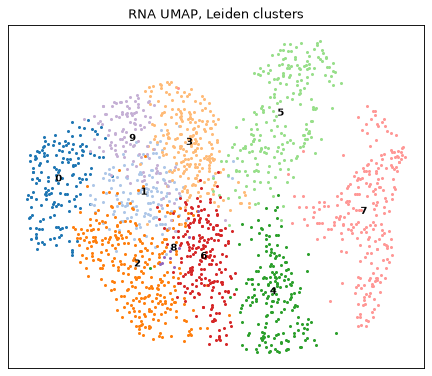

In [9]:
U = adata.obsm["X_umap_rna"]
lab = adata.obs["leiden"].astype(str)
fig, ax = plt.subplots(figsize=(5.5, 4.8))
for i, k in enumerate(adata.obs["leiden"].cat.categories):
    m = (lab == k).to_numpy()
    ax.scatter(U[m, 0], U[m, 1], s=3, color=plt.get_cmap("tab20")(i % 20), label=k)
    ax.text(U[m, 0].mean(), U[m, 1].mean(), k, fontsize=9, weight="bold", ha="center")
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("RNA UMAP, Leiden clusters"); fig.tight_layout()

## 6. Perturbation strength (direct knockdown)

Reference test: the target's own log-normalized expression in its perturbed cells versus non-targeting (`ntc`) and other-target (`other`) controls; log2FC on de-logged means, Kolmogorov-Smirnov and Mann-Whitney tests, BH-FDR per arm, effective knockdown = KS FDR < 0.05 and log2FC < 0. Tables from `tables/perturbation_strength/`.

In [ ]:
st = pd.read_csv(T / "perturbation_strength" / "perturbation_full.csv")
sk = pd.read_csv(T / "perturbation_strength" / "skipped.csv")
si = u["analysis"]["perturbation_effects"]["strength"]
print(f"{len(st)} targets tested, {int(st['is_hit_ntc'].sum())} effective knockdowns (control: {si['primary_control']}); skipped: {sk[['target', 'reason']].to_dict('records')}")
st[["rank", "target", "n_perturbed", "n_control_ntc", "log2fc_ntc", "pct_knockdown_ntc", "ks_stat_ntc", "ks_fdr_ntc", "is_hit_ntc", "log2fc_other", "ks_fdr_other", "is_hit_other"]].round(3)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.4))
o = st.sort_values("log2fc_ntc")
ax.bar(range(len(o)), o["log2fc_ntc"], color=["#c53030" if h else "#a0aec0" for h in o["is_hit_ntc"]])
ax.set_xticks(range(len(o))); ax.set_xticklabels(o["target"], rotation=90, fontsize=8); ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("log2FC of the target's own gene (vs NT)"); ax.set_title("Knockdown per target (red = effective)"); fig.tight_layout()

## 7. Perturbation x cluster enrichment

Reference test: per target and cluster, Fisher exact test (here a Cochran-Mantel-Haenszel test stratified by hashed sample, because `stratify_by: sample`) of the target's single-guide cells against both reference arms; `other` (all other targets) drives the significance calls, `ntc` is reported beside it. Table from `tables/cell_states/perturbation_cluster_enrichment.csv`.

In [ ]:
enr = pd.read_csv(T / "cell_states" / "perturbation_cluster_enrichment.csv")
e = u["analysis"]["cell_states"]["enrichment"]
print(f"{e['n_tests_per_control']} tests per control arm ({e['controls_used']}), primary {e['primary_control']}: {e['n_significant']} significant pairs at FDR < {e['fdr_alpha']} in {e['n_targets_with_hits']} targets; stratified={e['stratified']}")
print("omnibus:", {k: round(v, 4) if isinstance(v, float) else v for k, v in e["omnibus"].items()})
prim = enr[enr["control"] == e["primary_control"]]
sig = prim[prim["significant"]]
sig[["target", "cluster", "direction", "n_in_cluster", "n_target_cells", "pct_of_target", "n_reference_in_cluster", "pct_of_reference", "odds_ratio", "fdr", "guides_concordant", "guides_tested", "low_power"]].round(4).reset_index(drop=True)

In [ ]:
L = prim.pivot(index="target", columns="cluster", values="log2_odds_ratio")
S = prim.pivot(index="target", columns="cluster", values="significant").fillna(False)
L = L.loc[prim.groupby("target")["fdr"].min().sort_values().index]
fig, ax = plt.subplots(figsize=(6.5, 7))
lim = float(np.nanpercentile(np.abs(L.to_numpy()), 98))
im = ax.imshow(L.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
for i in range(L.shape[0]):
    for j in range(L.shape[1]):
        if bool(S.loc[L.index[i], L.columns[j]]):
            ax.text(j, i, "*", ha="center", va="center")
ax.set_xticks(range(L.shape[1])); ax.set_xticklabels(L.columns); ax.set_yticks(range(L.shape[0])); ax.set_yticklabels(L.index, fontsize=8)
ax.set_xlabel("Leiden cluster"); fig.colorbar(im, ax=ax, label="log2 odds ratio (Haldane)"); ax.set_title("target x cluster enrichment (* FDR < 0.05)"); fig.tight_layout()

In [ ]:
# composition of each target vs the reference and the total-variation shift
mag = pd.read_csv(T / "cell_states" / "enrichment_effect_magnitude.csv")
mag.head(10)

## 8. Perturbation-response score (PS)

Per cell, how much of its perturbation's transcriptional signature the cell shows (0 = like controls, 1 = the strongest response of that target; PS_python definition). Quadrants combine the score with the target's own expression: successful knockdown, escaper, non-responder, low signal. The summary is ordered by `pct_successful_kd` (reference order); `auc_vs_control` / `d_vs_control` are additions for cross-target comparison. The supervised LDA embedding is stored in `obsm['X_lda_umap']`.

In [ ]:
ps = pd.read_csv(T / "perturbation_effects" / "ps_targets.csv")
print(f"{len(ps)} targets scored; skipped: {pd.read_csv(T / 'perturbation_effects' / 'ps_skipped.csv')[['target', 'reason']].to_dict('records')}")
print("LDA:", u["analysis"]["perturbation_effects"]["ps"]["lda"])
ps[["target", "n_perturbed_cells", "median_ps", "pct_high_ps", "pct_successful_kd", "pct_escaper", "pct_non_responder", "pct_low_signal", "pct_controls_called_kd", "net_pct_kd", "auc_vs_control", "d_vs_control"]].round(3)

In [ ]:
pv = pd.read_csv(T / "perturbation_effects" / "ps_vs_perturbation.csv")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].scatter(pv["log2fc_ntc"], pv["pct_successful_kd"], c=["#c53030" if h else "#a0aec0" for h in pv["is_hit_ntc"]])
for _, r in pv.iterrows():
    axes[0].annotate(r["target"], (r["log2fc_ntc"], r["pct_successful_kd"]), fontsize=6)
axes[0].set_xlabel("direct knockdown log2FC (vs NT)"); axes[0].set_ylabel("% cells with confirmed knockdown (PS)"); axes[0].set_title("per-cell score vs group-level test")
X = adata.obsm["X_lda_umap"]; ok = np.isfinite(X).all(1); lab = adata.obs["lda_label"].astype(str).to_numpy()
for i, k in enumerate(sorted(set(lab[ok]))):
    m = ok & (lab == k)
    axes[1].scatter(X[m, 0], X[m, 1], s=3, color=plt.get_cmap("tab20")(i % 20), label=k)
axes[1].set_xticks([]); axes[1].set_yticks([]); axes[1].set_title(f"supervised LDA-UMAP ({int(ok.sum())} cells placed)"); axes[1].legend(fontsize=5, ncol=2, markerscale=3, frameon=False)
fig.tight_layout()

## 9. lochNESS

Cluster-free counterpart of section 7: for each cell, the enrichment of a target among its k = 300 nearest neighbours in PCA space relative to the target's overall frequency (0 = chance). The own-cell mean says whether a target's cells sit together; `top_cluster` is the Leiden cluster with the highest mean score. The permutation null is an optional extension (off in the demo, as in the reference).

In [ ]:
lo = pd.read_csv(T / "perturbation_effects" / "lochness_targets.csv")
li = u["analysis"]["perturbation_effects"]["lochness"]
print({k: li[k] for k in ("use_rep", "n_pcs", "k_used", "k_capped", "n_permutations")})
lo[["target", "n_cells", "overall_fraction_pct", "mean_lochness_in_own_cells", "max_lochness", "pct_cells_enriched", "top_cluster", "top_cluster_mean", "delta_own_vs_control"]].round(3).head(12)

In [ ]:
# cluster enrichment and lochNESS side by side (descriptive; no combined statistic)
cmp = pd.read_csv(T / "cell_states" / "cluster_enrichment_vs_lochness.csv")
cmp[["target", "n_cells", "n_clusters_significant", "top_enriched_cluster", "top_enriched_log2_or", "top_enriched_fdr", "lochness_own_mean", "lochness_top_cluster"]].round(3).head(12)

## 10. Co-functional modules

Perturbations clustered on the Spearman correlation of their log2FC profiles over the gene panel (union of the top Leiden-cluster markers; vs non-targeting controls; reference definition).

In [ ]:
mods = pd.read_csv(T / "perturbation_effects" / "perturbation_modules.csv")
mi = u["analysis"]["perturbation_effects"]["modules"]
print({k: mi[k] for k in ("gene_selection", "n_panel_genes", "control", "n_programs", "n_modules", "log2fc_pseudocount")})
print(mods.groupby("module")["target"].apply(list).to_dict())
pd.read_csv(T / "perturbation_effects" / "tf_hubs.csv").head(10)

## 11. Gene programs

Panel genes clustered on the Pearson correlation of their log2FC profiles across perturbations; per-cell program activity (`sc.tl.score_genes`) is stored in `obsm['program_activity']` and summarised per Leiden cluster.

In [ ]:
gp = pd.read_csv(T / "perturbation_effects" / "gene_programs.csv")
print("program sizes:", gp.groupby("program").size().to_dict())
display(gp.sort_values("mean_abs_log2fc", ascending=False).groupby("program").head(6).sort_values(["program", "mean_abs_log2fc"], ascending=[True, False])[["program", "gene", "mean_log2fc", "n_targets_up", "n_targets_down"]].round(2).reset_index(drop=True))
pd.read_csv(T / "perturbation_effects" / "program_activity_by_cluster.csv", index_col=0).round(3)

In [ ]:
pd.read_csv(T / "perturbation_effects" / "module_program_strength.csv", index_col=0).round(3)

## 12. Protein QC and representation

*Protein extension.* Four ADTs (CD86, PD-L1, PD-L2, TIM-3); raw counts in `obsm['protein_counts']`, per-protein CLR (across cells) in `obsm['protein']`, PCA on the scaled CLR block computed in float64 (stored float32) in `obsm['X_pca_protein']`, UMAP in `obsm['X_umap_protein']`. There are no isotype controls in this panel, so isotype-based QC is not applicable.

In [ ]:
feats = adata.uns["protein_features"]
display(feats[["role", "antibody_name", "protein_name", "gene_symbol", "in_counts", "used_in_embedding", "used_in_qc", "annotation_source"]])
C, P = adata.obsm["protein_counts"], adata.obsm["protein"]
pi_ = u["embeddings"]["protein"]["pca"]
print("proteins:", list(P.columns), "| isotypes:", list(feats.index[feats["is_isotype"].astype(bool)]) or "none")
print("counts: shape", C.shape, "dtype", C.dtypes.iloc[0], "| CLR: shape", P.shape, "dtype", P.dtypes.iloc[0], "non-finite", int((~np.isfinite(P.to_numpy())).sum()))
print("PCA:", adata.obsm["X_pca_protein"].shape, adata.obsm["X_pca_protein"].dtype, "working dtype", pi_["working_dtype"], "| variance ratio", pi_["variance_ratio"], "| UMAP:", adata.obsm["X_umap_protein"].shape)
print("protein QC flags:", {k: int(adata.obs[k].sum()) for k in adata.obs.columns if k.startswith("protein_") and adata.obs[k].dtype == bool})
pd.read_csv(T / "protein_qc.csv", index_col=0)[["role", "counts_median", "counts_q90", "counts_zero_frac", "norm_mean", "norm_median"]].round(3)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].hist(np.log10(adata.obs["protein_total_counts"] + 1), bins=50, color="#DD8452"); axes[0].set_xlabel("log10(total ADT counts + 1)"); axes[0].set_title("ADT depth")
im = axes[1].imshow(P.corr(method="spearman").to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1); axes[1].set_xticks(range(4)); axes[1].set_xticklabels(P.columns, rotation=90); axes[1].set_yticks(range(4)); axes[1].set_yticklabels(P.columns); axes[1].set_title("CLR Spearman correlation"); fig.colorbar(im, ax=axes[1])
U = adata.obsm["X_umap_protein"]; okp = np.isfinite(U).all(1)
sc_ = axes[2].scatter(U[okp, 0], U[okp, 1], c=P.loc[okp, "PDL1"], s=3, cmap="viridis"); axes[2].set_xticks([]); axes[2].set_yticks([]); axes[2].set_title("protein UMAP, coloured by PD-L1 CLR"); fig.colorbar(sc_, ax=axes[2])
fig.tight_layout()

## 13. Target x protein effects

*Protein extension.* For every target x protein pair: difference of CLR means (perturbed - non-targeting controls), Cohen's d, two-sided Mann-Whitney p, BH-FDR over all tests, sign consistency across hashed samples and across guides. All pairs are tested; the table is complete in `protein_effects.csv`.

In [ ]:
pe = pd.read_csv(T / "perturbation_effects" / "protein_effects.csv")
print(f"{len(pe)} target x protein tests ({pe['target'].nunique()} targets x {pe['protein'].nunique()} proteins), {int(pe['significant'].sum())} significant at FDR < 0.05")
pe.assign(abs_d=pe["cohen_d"].abs()).sort_values("abs_d", ascending=False)[["target", "protein", "n_perturbed", "n_control", "effect", "cohen_d", "p_value", "fdr", "significant", "n_samples_same_sign", "n_samples_tested", "n_guides_same_sign", "n_guides_tested"]].round(4).head(20).reset_index(drop=True)

In [ ]:
D = pd.read_csv(T / "perturbation_effects" / "protein_effect_matrix.csv", index_col=0)
Dd = pe.pivot(index="target", columns="protein", values="cohen_d").loc[D.index, D.columns]
Fq = pe.pivot(index="target", columns="protein", values="fdr").loc[D.index, D.columns] < 0.05
order = Dd.abs().max(axis=1).sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(4.5, 7))
lim = float(Dd.abs().max().max())
im = ax.imshow(Dd.loc[order].to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
for i, t in enumerate(order):
    for j, p_ in enumerate(D.columns):
        if bool(Fq.loc[t, p_]):
            ax.text(j, i, "*", ha="center", va="center")
ax.set_xticks(range(len(D.columns))); ax.set_xticklabels(D.columns); ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
fig.colorbar(im, ax=ax, label="Cohen's d"); ax.set_title("target x protein (* FDR < 0.05)"); fig.tight_layout()

## 14. RNA-protein concordance

*Protein extension; associations only.* (A) PS <-> protein within each target's cells (Spearman, BH-FDR over the within-target tests). (B) lochNESS <-> protein across targets, per protein (lochNESS is a population quantity; no cell-level correlation). (C) gene program <-> protein at the cell level and, separately, at the target level. (D) direct RNA knockdown vs protein effect is shown descriptively in the integrated summary; no cross-modal statistic exists for it in the current implementation.

In [ ]:
pp = pd.read_csv(T / "perturbation_effects" / "ps_protein_association.csv")
w = pp[pp["scope"] == "within_target"]
print(f"A. PS vs protein: {len(w)} within-target tests, {int((w['status'] == 'significant').sum())} significant")
display(w.assign(a=w["spearman_rho"].abs()).sort_values(["fdr", "a"], ascending=[True, False])[["target", "protein", "n_cells", "spearman_rho", "p_value", "fdr", "status"]].round(4).head(12).reset_index(drop=True))
R = w.pivot(index="target", columns="protein", values="spearman_rho"); Fq = w.pivot(index="target", columns="protein", values="fdr") < 0.05
fig, ax = plt.subplots(figsize=(4.5, 7)); im = ax.imshow(R.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
for i in range(R.shape[0]):
    for j in range(R.shape[1]):
        if bool(Fq.loc[R.index[i], R.columns[j]]): ax.text(j, i, "*", ha="center", va="center")
ax.set_xticks(range(R.shape[1])); ax.set_xticklabels(R.columns); ax.set_yticks(range(R.shape[0])); ax.set_yticklabels(R.index, fontsize=8); fig.colorbar(im, ax=ax, label="Spearman rho"); ax.set_title("PS <-> protein, within target"); fig.tight_layout()

In [ ]:
print("B. lochNESS <-> protein (target level, per protein):")
display(pd.read_csv(T / "perturbation_effects" / "lochness_protein_summary.csv").round(4))
lpa = pd.read_csv(T / "perturbation_effects" / "lochness_protein_association.csv")
lpa.assign(a=lpa["protein_effect"].abs()).sort_values("a", ascending=False)[["target", "protein", "n_cells", "lochness_own_mean", "protein_effect", "protein_fdr"]].round(4).head(8).reset_index(drop=True)

In [ ]:
ppc = pd.read_csv(T / "perturbation_effects" / "program_protein_association_cells.csv")
ppt = pd.read_csv(T / "perturbation_effects" / "program_protein_association_targets.csv")
print("C. program <-> protein, CELL level (activity vs protein over single-guide + control cells):"); display(ppc.sort_values("fdr")[["gene_program", "protein", "n_cells", "spearman_rho", "fdr", "status"]].round(4).reset_index(drop=True))
print("C. program <-> protein, TARGET level (program effect vs protein effect across targets):"); display(ppt.sort_values("fdr")[["gene_program", "protein", "n_targets", "spearman_rho", "fdr", "status"]].round(4).reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, (df, ttl) in zip(axes, ((ppc, "cell level"), (ppt, "target level"))):
    R = df.pivot(index="gene_program", columns="protein", values="spearman_rho")
    im = ax.imshow(R.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto"); ax.set_xticks(range(R.shape[1])); ax.set_xticklabels(R.columns); ax.set_yticks(range(R.shape[0])); ax.set_yticklabels(R.index); ax.set_title(f"program x protein rho ({ttl})")
    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            ax.text(j, i, f"{R.iat[i, j]:+.2f}", ha="center", va="center", fontsize=7, color="white" if abs(R.iat[i, j]) > 0.6 else "black")
    fig.colorbar(im, ax=ax)
fig.tight_layout()

## 15. Integrated RNA / protein target summary

One row per target, joining the stored results: direct knockdown (perturbation strength), PS, lochNESS, strongest cluster association and composition shift, module, strongest gene program, strongest protein effect, and the strongest PS-protein and program-protein associations (`tables/perturbation_effects/perturbation_summary.csv`). Nothing is recomputed.

In [ ]:
sm = pd.read_csv(T / "perturbation_effects" / "perturbation_summary.csv")
cols = ["target", "n_cells", "direct_rna_log2fc", "direct_rna_ks_fdr", "effective_knockdown", "ps_median", "ps_auc_vs_control", "lochness_own_mean", "strongest_cluster", "strongest_cluster_direction", "cluster_enrichment_log2_or", "cluster_enrichment_fdr", "cluster_composition_shift_pct", "module", "n_de_genes", "strongest_gene_program", "gene_program_effect", "strongest_protein", "protein_effect_magnitude", "n_proteins_significant", "ps_protein_best", "strongest_program_protein_association"]
sm.sort_values("direct_rna_log2fc")[[c for c in cols if c in sm.columns]].round(3).reset_index(drop=True)

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ok = sm["direct_rna_log2fc"].notna()
ax.scatter(sm.loc[ok, "direct_rna_log2fc"], sm.loc[ok, "protein_effect_magnitude"], c=["#c53030" if h else "#4C72B0" for h in sm.loc[ok, "effective_knockdown"].eq(True)], s=40)
for _, r in sm[ok].iterrows():
    ax.annotate(r["target"], (r["direct_rna_log2fc"], r["protein_effect_magnitude"]), fontsize=7)
ax.set_xlabel("direct knockdown log2FC (target's own gene vs NT)"); ax.set_ylabel("largest |Cohen's d| over the 4 proteins"); ax.set_title("RNA knockdown vs protein effect per target (red = effective knockdown)"); fig.tight_layout()

## 16. Report and output files

* `report.html` - the complete report in the reference section order (QC, clustering, perturbation strength, cluster enrichment, PS, lochNESS, modules/programs) followed by the protein extension (protein QC, protein effects, RNA-protein concordance, multimodal summaries); every figure embedded. `report.md` mirrors it.
* `processed/papalexi_eccite_demo_processed.h5ad` - everything shown here, in one object (`docs/PROCESSED_OBJECT.md`).
* `tables/` - every number in the report as CSV (`tables/cell_states/`, `tables/perturbation_strength/`, `tables/perturbation_effects/`).
* `figures/` - every figure, listed in `tables/figure_manifest.csv`.
* `logs/` - `run.log`, `resolved_config.yaml`, `run_manifest.json`.

In [ ]:
print("report:", RESULTS.name + "/report.html", "exists:", (RESULTS / "report.html").exists())
man = pd.read_csv(T / "figure_manifest.csv")
man.groupby(["section", "stage"]).agg(figures=("name", "size"), embedded=("in_report", "sum"))